In [1]:
import os
from virtual_accelerator.models.facet2 import get_facet_bmad_model
os.environ["FACET2_LATTICE"] = "/sdf/data/ad/ard-online/cropp/facet2-lattice"

model = get_facet_bmad_model(
    track_beam=True,
    start_element="L0AFEND",
    end_element="PR10571",
)

Failed to set custom alias for element PR10241: Command: 'set ele PR10241 alias = PROF:IN10:241' causes errors in the function(s): tao_locate_all_elements

Error in tao_locate_all_elements:
  ELEMENT(S) NOT FOUND: PR10241
Failed to set custom alias for element PR10711: Command: 'set ele PR10711 alias = PROF:IN10:711' causes errors in the function(s): tao_locate_all_elements

Error in tao_locate_all_elements:
  ELEMENT(S) NOT FOUND: PR10711
Element type Lcavity for element L0BF not found in variable configuration mapping. Skipping.
Error getting element type for UM10466: Command: 'pipe ele:head UM10466|model' causes errors in the function(s): tao_pipe_cmd

Error in tao_pipe_cmd:
  "pipe ele:head UM10466|model": Multiple matches to element: UM10466. Defaulting to 'Unknown'.
Element type Unknown for element UM10466 not found in variable configuration mapping. Skipping.
Error getting element type for UM10466: Command: 'pipe ele:head UM10466|model' causes errors in the function(s): tao_pipe

In [2]:
variable_names = list(model.supported_variables.keys())
print(f"Supported variables: {len(variable_names)}")
print("Example variable names:")
print(variable_names[:10])

Supported variables: 251
Example variable names:
['QUAD:IN10:361:BCTRL', 'QUAD:IN10:361:BCTRL.DRVL', 'QUAD:IN10:361:BCTRL.DRVH', 'QUAD:IN10:361:BACT', 'QUAD:IN10:361:BDES', 'QUAD:IN10:361:BMAX', 'QUAD:IN10:361:BMIN', 'QUAD:IN10:361:STATCTRLSUB.T', 'QUAD:IN10:361:CTRL', 'QUAD:IN10:371:BCTRL']


## Predictions at elements

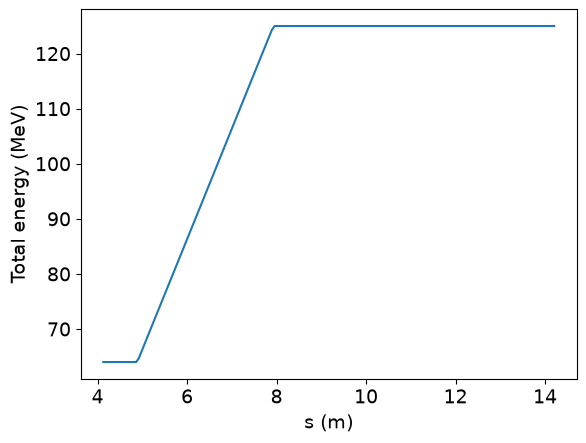

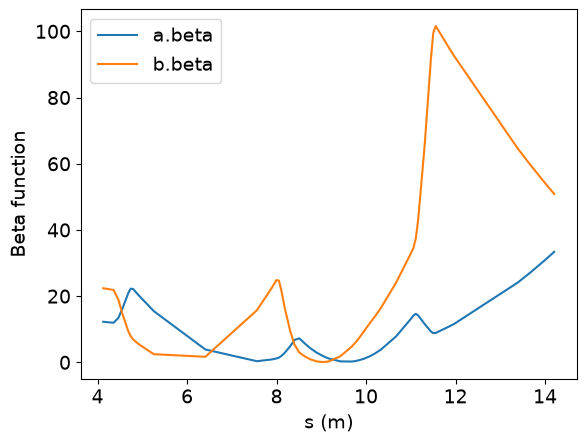

In [3]:
import matplotlib.pyplot as plt

out = model.get(["s_ele", "a.beta", "b.beta", "e_tot"])
plt.plot(out["s_ele"], out["e_tot"] / 1e6, label="b")
plt.ylabel("Total energy (MeV)")
plt.xlabel("s (m)")

plt.figure()
plt.plot(out["s_ele"], out["a.beta"], label="a.beta")
plt.plot(out["s_ele"], out["b.beta"], label="b.beta")
plt.xlabel("s (m)")
plt.ylabel("Beta function")
plt.legend()

## Predictions using comb

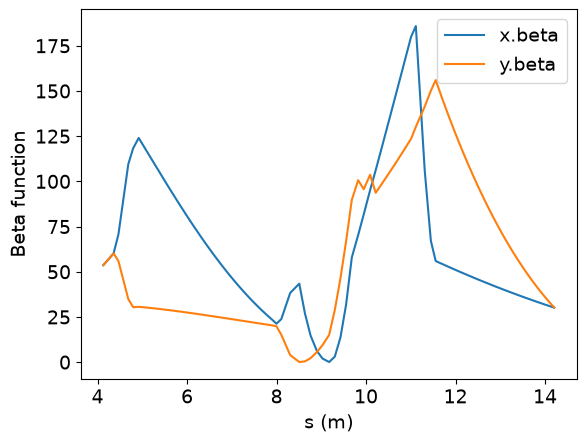

In [4]:
import matplotlib.pyplot as plt

out = model.get(["s", "x.beta", "y.beta"])

plt.figure()
plt.plot(out["s"], out["x.beta"], label="x.beta")
plt.plot(out["s"], out["y.beta"], label="y.beta")
plt.xlabel("s (m)")
plt.ylabel("Beta function")
plt.legend()

## Staged FACET-II model

In [ ]:
from virtual_accelerator.models.facet2 import get_facet_staged_model

staged_model = get_facet_staged_model(
    surrogate_inputs="machine", n_particles=10000, end_element="PR10711"
)

In [ ]:
import matplotlib.pyplot as plt

out = staged_model.get(["s", "x.beta", "y.beta", "s_ele", "a.beta", "b.beta"])
plt.plot(out["s"], out["x.beta"], label="tracked x.beta")
plt.plot(out["s"], out["y.beta"], label="tracked y.beta")
plt.plot(out["s_ele"], out["a.beta"], "--", label="design a.beta")
plt.plot(out["s_ele"], out["b.beta"], "--", label="design b.beta")
plt.xlabel("s (m)")
plt.ylabel("Beta function")
plt.legend()

## Staged model with Impact

In [ ]:
import matplotlib.pyplot as plt
from virtual_accelerator.models.facet2 import (
    get_facet_impact_model,
    get_facet_bmad_model,
)
from lume.staged_model import StagedModel
from virtual_accelerator.registry import (
    get_model
)
from virtual_accelerator.registry.models import MODELS

impact_model = get_facet_impact_model(n_particles=1000, end_element="PR10241")

facet_bmad_model = get_facet_bmad_model(
    start_element="PR10241",
    end_element="TD11",
    track_beam=True,
)

staged_model = get_model(["impact_f2e_inj", "bmad_f2_elec"], end_ele="PR10711", n_particles=200) 

Element type Multipole for element SQ10122 not found in variable configuration mapping. Skipping.
Element type Multipole for element CQ10121 not found in variable configuration mapping. Skipping.
Element type Lcavity for element L0AF not found in variable configuration mapping. Skipping.
Element type Lcavity for element L0BF not found in variable configuration mapping. Skipping.
Error getting element type for UM10466: Command: 'pipe ele:head UM10466|model' causes errors in the function(s): tao_pipe_cmd

Error in tao_pipe_cmd:
  "pipe ele:head UM10466|model": Multiple matches to element: UM10466. Defaulting to 'Unknown'.
Element type Unknown for element UM10466 not found in variable configuration mapping. Skipping.
Element type Monitor for element BZ10596 not found in variable configuration mapping. Skipping.
Error getting element type for K11_1: Command: 'pipe ele:head K11_1|model' causes errors in the function(s): tao_pipe_cmd

Error in tao_pipe_cmd:
  "pipe ele:head K11_1|model": Can

ValueError: Variable 'SOLN:IN10:111:BCTRL' is defined in both model 0 and model 1.

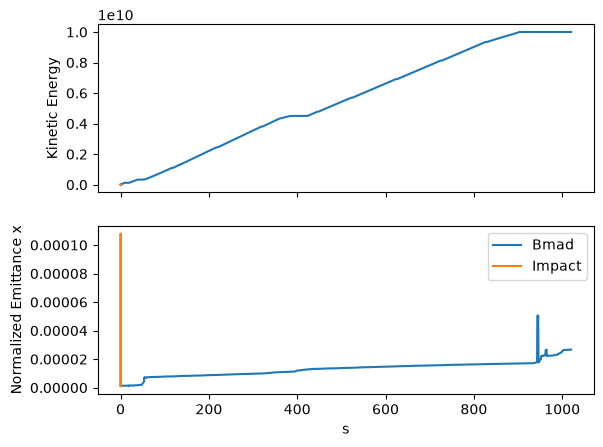

In [ ]:
# plot the staged model
info = staged_model.get(
    [
        "s",
        "s_ele",
        "p0c",
        "stat:mean_z",
        "stat:mean_kinetic_energy",
        "stat:norm_emit_x",
        "x.norm_emit",
        "stat:",
    ]
)

fig, ax = plt.subplots(2, 1, sharex=True)

ax[0].plot(info["s_ele"], info["p0c"])
ax[0].plot(info["stat:mean_z"], info["stat:mean_kinetic_energy"])
ax[0].set_ylabel("Kinetic Energy")
ax[1].plot(info["s"], info["x.norm_emit"], label="Bmad")
ax[1].plot(info["stat:mean_z"], info["stat:norm_emit_x"], label="Impact")
ax[1].set_xlabel("s")
ax[1].set_ylabel("Normalized Emittance x")
ax[1].legend()

Text(0, 0.5, 'RMS Beam Size')

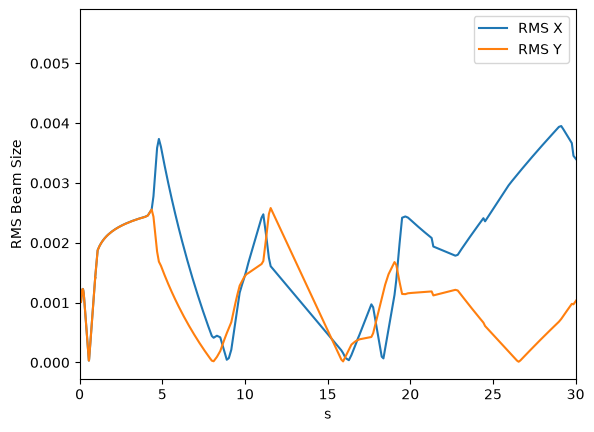

In [32]:
import numpy as np

s_tot = np.append(staged_model.get("stat:mean_z"), staged_model.get("s"))
rms_x = np.append(
    staged_model.get("stat:sigma_x"),
    (staged_model.get("x.emit") * staged_model.get("x.beta")) ** 0.5,
)
rms_y = np.append(
    staged_model.get("stat:sigma_y"),
    (staged_model.get("y.emit") * staged_model.get("y.beta")) ** 0.5,
)
plt.plot(s_tot, rms_x, label="RMS X")
plt.plot(s_tot, rms_y, label="RMS Y")
plt.legend()
plt.xlim(0, 30)
plt.xlabel("s")
plt.ylabel("RMS Beam Size")